# Face-center coordinates

Prepared for Shivam Singh · MathTech

## Theory
For a box (x,y,w,h), center is (x+w/2,y+h/2). Center and Cartesian origins differ in Y direction. The processing resolution defines pixel units.

## Imports

In [1]:
from pathlib import Path
import sys
import numpy as np
import cv2
import matplotlib.pyplot as plt
from dataclasses import replace
from face_motion_lab.config.settings import Settings
from face_motion_lab.types import Box, Landmarks
from face_motion_lab.input.synthetic import demo_frame, SyntheticDetector
from face_motion_lab.pipeline import Pipeline
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True})
settings = Settings()


## Implementation

In [2]:
from face_motion_lab.analysis.coordinates import coordinates
box = Box(250, 160, 100, 140)
for origin in ("top-left", "center", "cartesian"):
    print(coordinates(*box.center, 800, 480, origin))
pipeline = Pipeline(settings, SyntheticDetector())
for i in range(80):
    result = pipeline.process(demo_frame(i), i/30, i)
    if i == 0: pipeline.lock(1)
rows = pipeline.analysis.rows()


{'x': 300.0, 'y': 230.0, 'x_norm': 0.375, 'y_norm': 0.4791666666666667, 'origin': 'top-left'}
{'x': -100.0, 'y': -10.0, 'x_norm': -0.125, 'y_norm': -0.020833333333333332, 'origin': 'center'}
{'x': -100.0, 'y': 10.0, 'x_norm': -0.125, 'y_norm': 0.020833333333333332, 'origin': 'cartesian'}


## Visualization

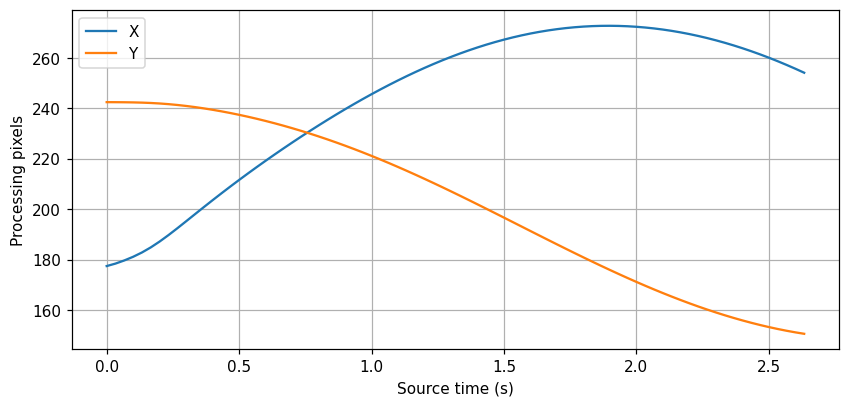

In [3]:
t = [r["timestamp"] for r in rows]
plt.plot(t, [r["cx"] for r in rows], label="X")
plt.plot(t, [r["cy"] for r in rows], label="Y")
plt.xlabel("Source time (s)"); plt.ylabel("Processing pixels"); plt.legend(); plt.show()


## Experiment

In [4]:
a = coordinates(400, 240, 800, 480, "cartesian")
assert a["x"] == 0 and a["y"] == 0
b = coordinates(0, 0, 800, 480, "cartesian")
assert b["x_norm"] == -0.5 and b["y_norm"] == 0.5
print("Origin checks passed")
pipeline.close()


Origin checks passed


## Observations
Change processing_width to 640 and compare pixel values. Normalized positions should stay comparable; do not compare pixel velocities across resolutions without scale conversion.

## Conclusion
Always export coordinate conventions and processing resolution alongside measurements.